In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Set pandas options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
print("\nUpload the cleaned dataset:")


uploaded = files.upload()
filename = list(uploaded.keys())[0]

print(f"\n File uploaded: {filename}")


Upload the cleaned dataset:


Saving matches_cleaned.csv to matches_cleaned.csv

 File uploaded: matches_cleaned.csv


In [3]:
# Load the data
df = pd.read_csv(filename)

print(f"\n Data loaded successfully!")
print(f"   Matches: {len(df):,}")
print(f"   Columns: {len(df.columns)}")

# Check for raw data
day2_features = ['win_margin_type', 'win_margin_value', 'toss_match_win',
                 'close_match', 'total_runs']
missing_features = [f for f in day2_features if f not in df.columns]

if missing_features:
    print(f"\n  Warning: Missing features : {missing_features}")
    print("   Make sure you uploaded the cleaned dataset!")
else:
    print(f"\n All the data are present")

# Show first few rows
print("\n📋 Sample data:")
display(df[['match_id', 'season', 'team1', 'team2', 'match_won_by',
            'win_margin_type', 'total_runs']].head())


 Data loaded successfully!
   Matches: 1,193
   Columns: 29

 All the data are present

📋 Sample data:


,match_id,season,team1,team2,match_won_by,win_margin_type,total_runs
0,335982,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,runs,304
1,335983,NaN,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,runs,447
2,335984,NaN,Rajasthan Royals,Delhi Daredevils,Delhi Daredevils,wickets,261
3,335985,NaN,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,wickets,331
4,335986,NaN,Deccan Chargers,Kolkata Knight Riders,Kolkata Knight Riders,wickets,222


### **STEP 1 : Team Performance Analysis**

In [4]:
# Get all unique teams
all_teams = set(df['team1'].unique()) | set(df['team2'].unique())
all_teams = sorted([t for t in all_teams if pd.notna(t) and t != 'No Result'])

# Initialize results dictionary
team_stats = []

for team in all_teams:
    # Count total matches (as team1 or team2)
    total_matches = len(df[(df['team1'] == team) | (df['team2'] == team)])

    # Count wins
    wins = len(df[df['match_won_by'] == team])

    # Count losses
    losses = total_matches - wins

    # Calculate win percentage
    win_pct = (wins / total_matches * 100) if total_matches > 0 else 0

    team_stats.append({
        'Team': team,
        'Matches': total_matches,
        'Wins': wins,
        'Losses': losses,
        'Win_Percentage': round(win_pct, 2)
    })

# Create DataFrame
team_performance = pd.DataFrame(team_stats).sort_values('Win_Percentage', ascending=False)

print(f"✅ Analyzed {len(team_performance)} teams")
print("\n📊 TEAM WIN RATES (Top 10):")
print(team_performance.head(10).to_string(index=False))

✅ Analyzed 17 teams

📊 TEAM WIN RATES (Top 10):
                       Team  Matches  Wins  Losses  Win_Percentage
             Gujarat Titans       64    39      25           60.94
        Chennai Super Kings      256   144     112           56.25
             Mumbai Indians      282   152     130           53.90
       Lucknow Super Giants       63    32      31           50.79
      Kolkata Knight Riders      269   135     134           50.19
    Rising Pune Supergiants       30    15      15           50.00
Royal Challengers Bangalore      275   136     139           49.45
           Rajasthan Royals      239   118     121           49.37
               Punjab Kings       78    38      40           48.72
             Delhi Capitals      109    53      56           48.62


### **STEP 2 : Team Scoring Pattern**

In [5]:
team_scoring = []

for team in all_teams:
    # When batting first (team1)
    batting_first = df[df['team1'] == team]
    avg_scored_first = batting_first['team1_runs'].mean()

    # When batting second (team2)
    batting_second = df[df['team2'] == team]
    avg_scored_second = batting_second['team2_runs'].mean()

    # Overall average
    all_scores = pd.concat([
        batting_first['team1_runs'],
        batting_second['team2_runs']
    ])
    avg_total = all_scores.mean()

    # Runs conceded (when bowling)
    bowling_first = df[df['team2'] == team]  # Team2 bowls first
    bowling_second = df[df['team1'] == team]  # Team1 bowls second

    all_conceded = pd.concat([
        bowling_first['team1_runs'],
        bowling_second['team2_runs']
    ])
    avg_conceded = all_conceded.mean()

    team_scoring.append({
        'Team': team,
        'Avg_Runs_Scored': round(avg_total, 1),
        'Avg_Runs_Conceded': round(avg_conceded, 1),
        'Run_Differential': round(avg_total - avg_conceded, 1)
    })

scoring_df = pd.DataFrame(team_scoring).sort_values('Run_Differential', ascending=False)

print("✅ Calculated scoring patterns")
print("\n📊 TEAM SCORING STATS (Top 10):")
print(scoring_df.head(10).to_string(index=False))

✅ Calculated scoring patterns

📊 TEAM SCORING STATS (Top 10):
                       Team  Avg_Runs_Scored  Avg_Runs_Conceded  Run_Differential
        Chennai Super Kings            164.1              158.1               6.0
             Gujarat Titans            178.0              173.4               4.5
             Mumbai Indians            163.0              159.4               3.7
               Punjab Kings            174.3              171.8               2.5
        Sunrisers Hyderabad            162.9              162.1               0.7
    Rising Pune Supergiants            151.1              151.6              -0.5
Royal Challengers Bangalore            161.0              161.9              -0.8
      Kolkata Knight Riders            156.3              157.3              -1.0
           Rajasthan Royals            159.7              161.3              -1.6
       Lucknow Super Giants            175.2              177.3              -2.1


### **STEP 3 : Toss Analysis by Team**

In [6]:
toss_stats = []

for team in all_teams:
    # Matches where team won toss
    toss_won = df[df['toss_winner'] == team]
    toss_count = len(toss_won)

    # Of those, how many did they win?
    toss_and_match = len(toss_won[toss_won['match_won_by'] == team])

    # Calculate toss win percentage
    toss_win_pct = (toss_and_match / toss_count * 100) if toss_count > 0 else 0

    # Bat vs field preference
    bat_decision = len(toss_won[toss_won['toss_decision'] == 'bat'])
    field_decision = len(toss_won[toss_won['toss_decision'] == 'field'])

    toss_stats.append({
        'Team': team,
        'Toss_Wins': toss_count,
        'Match_Wins_After_Toss': toss_and_match,
        'Toss_Match_Win_Pct': round(toss_win_pct, 1),
        'Prefer_Bat': bat_decision,
        'Prefer_Field': field_decision
    })

toss_df = pd.DataFrame(toss_stats).sort_values('Toss_Match_Win_Pct', ascending=False)

print("✅ Toss analysis complete")
print("\n📊 TOSS IMPACT BY TEAM (Top 10):")
print(toss_df.head(10).to_string(index=False))

✅ Toss analysis complete

📊 TOSS IMPACT BY TEAM (Top 10):
                       Team  Toss_Wins  Match_Wins_After_Toss  Toss_Match_Win_Pct  Prefer_Bat  Prefer_Field
              Gujarat Lions         15                     10                66.7           1            14
             Gujarat Titans         30                     20                66.7           6            24
    Rising Pune Supergiants         13                      8                61.5           3            10
        Chennai Super Kings        129                     78                60.5          60            69
       Lucknow Super Giants         26                     15                57.7           7            19
      Kolkata Knight Riders        131                     71                54.2          41            90
             Mumbai Indians        154                     83                53.9          54           100
Royal Challengers Bangalore        130                     68                5

### **STEP 4 : Venue Analysis**

In [7]:
venue_stats = []

for venue in df['venue'].dropna().unique():
    venue_matches = df[df['venue'] == venue]

    # Number of matches
    total_matches = len(venue_matches)

    # Average total runs
    avg_runs = venue_matches['total_runs'].mean()

    # High scoring matches (200+)
    high_scoring = venue_matches['high_scoring'].sum()
    high_scoring_pct = (high_scoring / total_matches * 100)

    # Close matches
    close_matches = venue_matches['close_match'].sum()
    close_pct = (close_matches / total_matches * 100)

    # Runs scored batting first vs second
    avg_first_innings = venue_matches['team1_runs'].mean()
    avg_second_innings = venue_matches['team2_runs'].mean()

    venue_stats.append({
        'Venue': venue,
        'Matches': total_matches,
        'Avg_Total_Runs': round(avg_runs, 1),
        'Avg_1st_Innings': round(avg_first_innings, 1),
        'Avg_2nd_Innings': round(avg_second_innings, 1),
        'High_Scoring_Pct': round(high_scoring_pct, 1),
        'Close_Match_Pct': round(close_pct, 1)
    })

venue_df = pd.DataFrame(venue_stats).sort_values('Avg_Total_Runs', ascending=False)

print("✅ Analyzed venues")
print(f"\n📊 HIGHEST SCORING VENUES (Top 10):")
print(venue_df.head(10)[['Venue', 'Matches', 'Avg_Total_Runs',
                          'High_Scoring_Pct']].to_string(index=False))

print(f"\n📊 MOST EXCITING VENUES (By close matches):")
close_venues = venue_df.sort_values('Close_Match_Pct', ascending=False)
print(close_venues.head(10)[['Venue', 'Matches', 'Close_Match_Pct']].to_string(index=False))

✅ Analyzed venues

📊 HIGHEST SCORING VENUES (Top 10):
                                                                Venue  Matches  Avg_Total_Runs  High_Scoring_Pct
                                                 Arun Jaitley Stadium       39           361.1              35.9
                                     Narendra Modi Stadium, Ahmedabad       34           358.4              47.1
                                                    Brabourne Stadium       27           344.6              25.9
              Maharaja Yadavindra Singh International Cricket Stadium       13           337.6              30.8
                                                     Wankhede Stadium      128           332.8              16.4
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow       24           331.6              20.8
                               Saurashtra Cricket Association Stadium       10           331.6              10.0
                         Himachal Pradesh 

### **STEP 5 : Home Advantage Analysis**

In [8]:
home_advantage = []

for team in all_teams:
    # Home matches (team1_home=1 or team2_home=1)
    home_matches = df[
        ((df['team1'] == team) & (df['team1_home'] == 1)) |
        ((df['team2'] == team) & (df['team2_home'] == 1))
    ]
    home_count = len(home_matches)
    home_wins = len(home_matches[home_matches['match_won_by'] == team])
    home_win_pct = (home_wins / home_count * 100) if home_count > 0 else 0

    # Away matches
    away_matches = df[
        ((df['team1'] == team) & (df['team1_home'] == 0)) |
        ((df['team2'] == team) & (df['team2_home'] == 0))
    ]
    away_count = len(away_matches)
    away_wins = len(away_matches[away_matches['match_won_by'] == team])
    away_win_pct = (away_wins / away_count * 100) if away_count > 0 else 0

    # Calculate advantage
    advantage = home_win_pct - away_win_pct

    home_advantage.append({
        'Team': team,
        'Home_Matches': home_count,
        'Home_Win_Pct': round(home_win_pct, 1),
        'Away_Matches': away_count,
        'Away_Win_Pct': round(away_win_pct, 1),
        'Home_Advantage': round(advantage, 1)
    })

home_df = pd.DataFrame(home_advantage).sort_values('Home_Advantage', ascending=False)

print("✅ Home advantage calculated")
print("\n📊 TEAMS WITH STRONGEST HOME ADVANTAGE:")
print(home_df[home_df['Home_Matches'] >= 10].head(10).to_string(index=False))

✅ Home advantage calculated

📊 TEAMS WITH STRONGEST HOME ADVANTAGE:
                       Team  Home_Matches  Home_Win_Pct  Away_Matches  Away_Win_Pct  Home_Advantage
        Sunrisers Hyderabad            64          59.4           136          41.9            17.5
           Rajasthan Royals            62          61.3           177          45.2            16.1
        Chennai Super Kings            80          66.2           176          51.7            14.5
             Mumbai Indians           114          60.5           168          49.4            11.1
      Kolkata Knight Riders            98          55.1           171          47.4             7.7
           Delhi Daredevils            63          42.9            98          40.8             2.0
              Pune Warriors            16          25.0            29          27.6            -2.6
Royal Challengers Bangalore            61          45.9           214          50.5            -4.6
    Rising Pune Supergiants     

### **STEP 6 : Head - Head Analysis**

In [9]:
h2h_matrix = pd.DataFrame(index=all_teams, columns=all_teams)

for team1 in all_teams:
    for team2 in all_teams:
        if team1 == team2:
            h2h_matrix.loc[team1, team2] = '-'
        else:
            # Matches between these two teams
            matches = df[
                ((df['team1'] == team1) & (df['team2'] == team2)) |
                ((df['team1'] == team2) & (df['team2'] == team1))
            ]

            # Wins by team1
            wins = len(matches[matches['match_won_by'] == team1])
            total = len(matches)

            if total > 0:
                h2h_matrix.loc[team1, team2] = f"{wins}/{total}"
            else:
                h2h_matrix.loc[team1, team2] = "0/0"

print("✅ Head-to-head matrix created")
print("\n📊 SAMPLE - MI vs other teams:")
if 'Mumbai Indians' in all_teams:
    print(h2h_matrix.loc['Mumbai Indians'].head(10))

✅ Head-to-head matrix created

📊 SAMPLE - MI vs other teams:
Chennai Super Kings      21/39
Deccan Chargers           6/10
Delhi Capitals           10/16
Delhi Daredevils         11/22
Gujarat Lions              1/4
Gujarat Titans             3/8
Kings XI Punjab          14/26
Kochi Tuskers Kerala       0/1
Kolkata Knight Riders    25/36
Lucknow Super Giants       2/8
Name: Mumbai Indians, dtype: object


### **STEP 7 : Seasonal Trends**

In [10]:
seasonal_trends = df.groupby('season').agg({
    'match_id': 'count',  # Total matches
    'total_runs': 'mean',  # Average runs
    'close_match': 'sum',  # Close matches
    'high_scoring': 'sum',  # High scoring matches
    'toss_match_win': 'mean'  # Toss impact
}).round(2)

seasonal_trends.columns = ['Matches', 'Avg_Total_Runs', 'Close_Matches',
                           'High_Scoring', 'Toss_Win_Rate']

# Convert toss win rate to percentage
seasonal_trends['Toss_Win_Rate'] = (seasonal_trends['Toss_Win_Rate'] * 100).round(1)

print("✅ Seasonal trends calculated")
print("\n📊 SEASON-BY-SEASON TRENDS:")
print(seasonal_trends)

✅ Seasonal trends calculated

📊 SEASON-BY-SEASON TRENDS:
        Matches  Avg_Total_Runs  Close_Matches  High_Scoring  Toss_Win_Rate
season                                                                     
2009.0       57          286.32             10             1           58.0
2011.0       73          289.78              7             4           52.0
2012.0       74          303.42              8             4           45.0
2013.0       76          296.59              9             4           46.0
2014.0       60          315.15              5             6           48.0
2015.0       59          310.71             13             7           46.0
2016.0       60          314.37             10             5           57.0
2017.0       59          318.12              8             8           58.0
2018.0       60          331.68              9            11           53.0
2019.0       60          323.33              8             9           57.0
2021.0       60          310.37

### **STEP 8 : Visualizations**

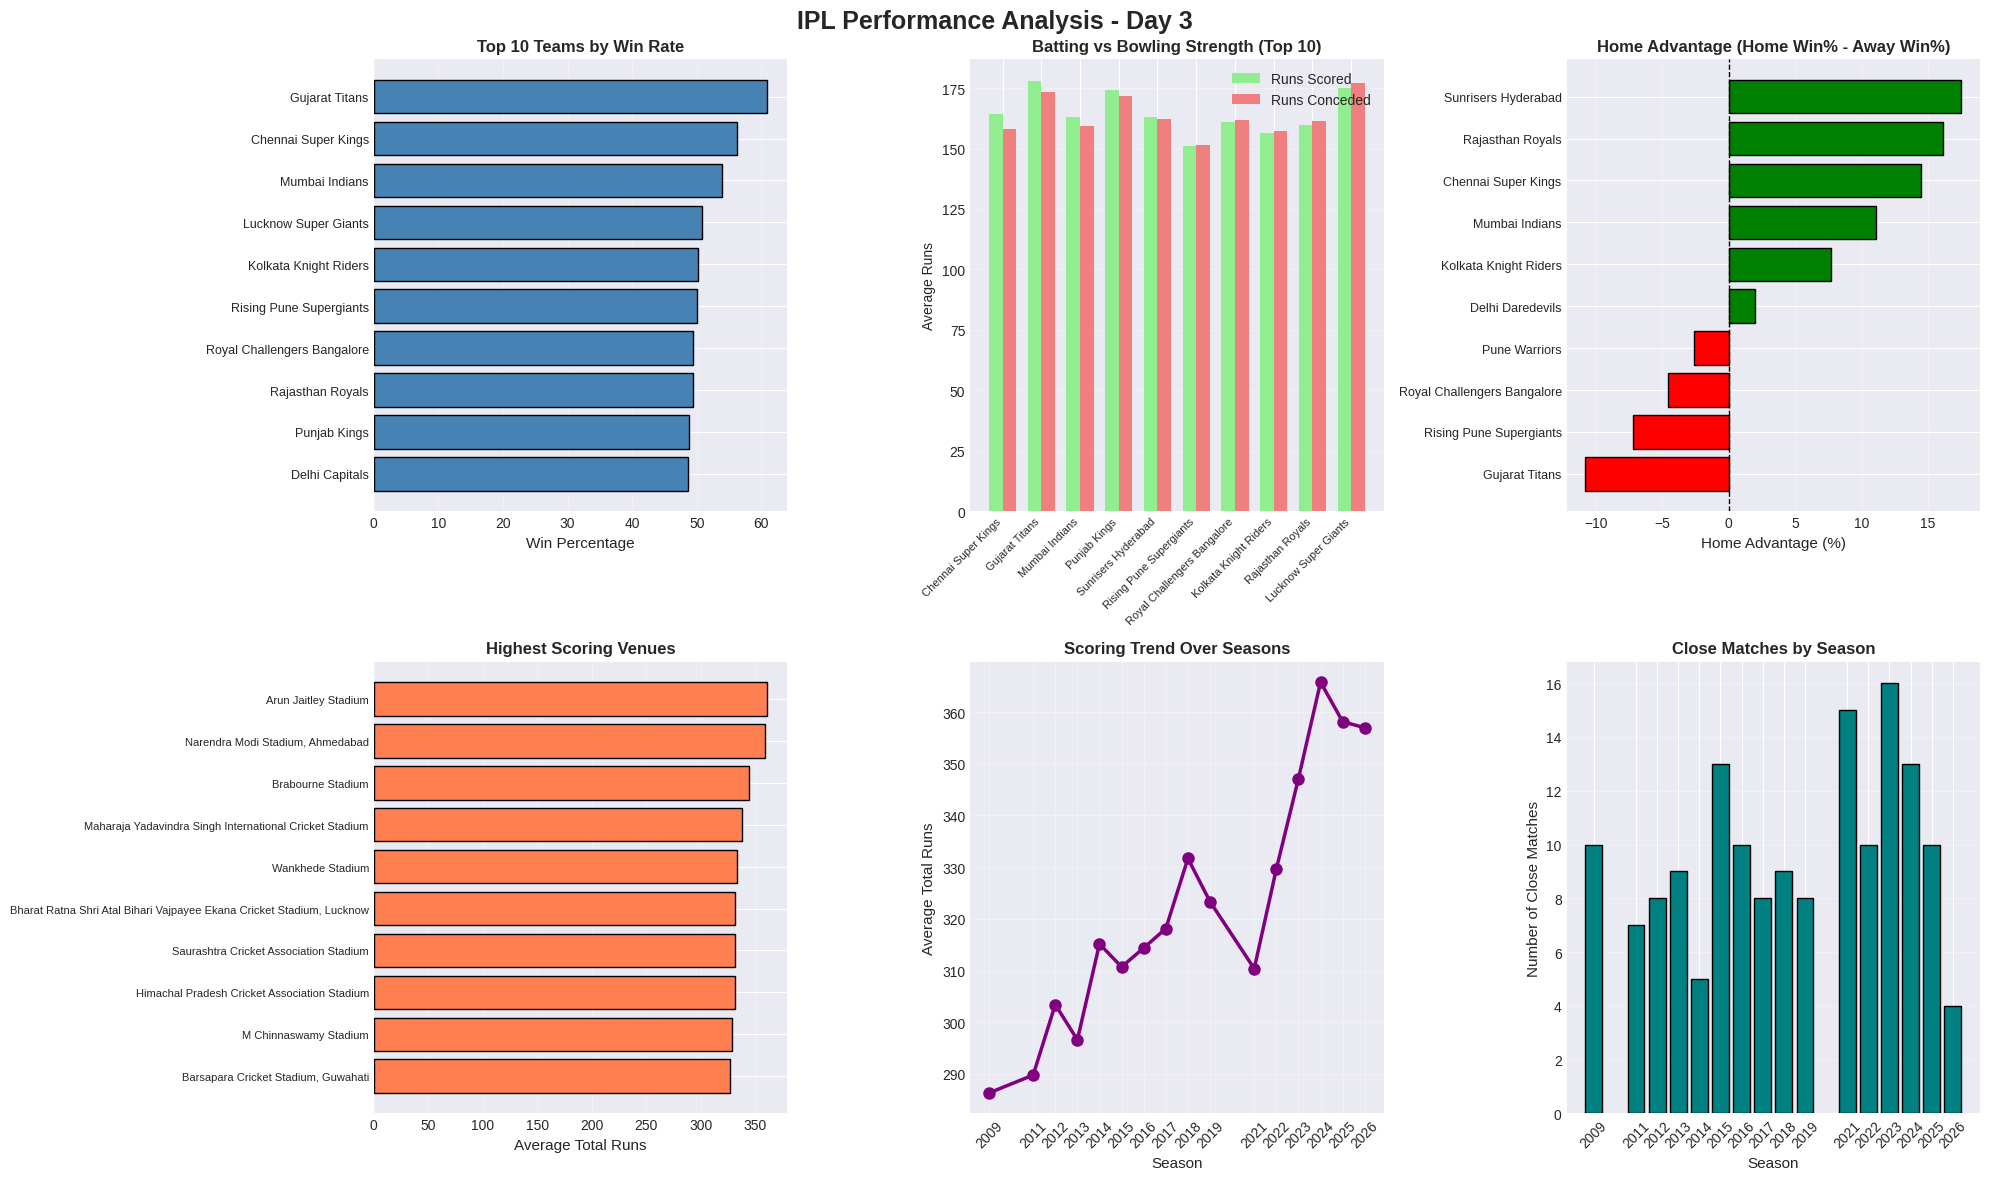

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('IPL Performance Analysis - Day 3', fontsize=18, fontweight='bold')

# Chart 1: Top teams by win percentage
top_teams = team_performance.head(10)
axes[0, 0].barh(range(len(top_teams)), top_teams['Win_Percentage'],
                color='steelblue', edgecolor='black')
axes[0, 0].set_yticks(range(len(top_teams)))
axes[0, 0].set_yticklabels(top_teams['Team'], fontsize=9)
axes[0, 0].set_xlabel('Win Percentage', fontsize=11)
axes[0, 0].set_title('Top 10 Teams by Win Rate', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Chart 2: Scoring patterns
top_scoring = scoring_df.head(10)
x = np.arange(len(top_scoring))
width = 0.35
axes[0, 1].bar(x - width/2, top_scoring['Avg_Runs_Scored'], width,
               label='Runs Scored', color='lightgreen')
axes[0, 1].bar(x + width/2, top_scoring['Avg_Runs_Conceded'], width,
               label='Runs Conceded', color='lightcoral')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(top_scoring['Team'], rotation=45, ha='right', fontsize=8)
axes[0, 1].set_ylabel('Average Runs')
axes[0, 1].set_title('Batting vs Bowling Strength (Top 10)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Chart 3: Home advantage
top_home = home_df[home_df['Home_Matches'] >= 10].head(10)
axes[0, 2].barh(range(len(top_home)), top_home['Home_Advantage'],
                color=['green' if x > 0 else 'red' for x in top_home['Home_Advantage']],
                edgecolor='black')
axes[0, 2].set_yticks(range(len(top_home)))
axes[0, 2].set_yticklabels(top_home['Team'], fontsize=9)
axes[0, 2].set_xlabel('Home Advantage (%)', fontsize=11)
axes[0, 2].set_title('Home Advantage (Home Win% - Away Win%)', fontsize=12, fontweight='bold')
axes[0, 2].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0, 2].invert_yaxis()
axes[0, 2].grid(axis='x', alpha=0.3)

# Chart 4: Venue scoring
top_venues_chart = venue_df.head(10)
axes[1, 0].barh(range(len(top_venues_chart)), top_venues_chart['Avg_Total_Runs'],
                color='coral', edgecolor='black')
axes[1, 0].set_yticks(range(len(top_venues_chart)))
axes[1, 0].set_yticklabels(top_venues_chart['Venue'], fontsize=8)
axes[1, 0].set_xlabel('Average Total Runs', fontsize=11)
axes[1, 0].set_title('Highest Scoring Venues', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Chart 5: Seasonal scoring trend
seasons = seasonal_trends.index.astype(int)
axes[1, 1].plot(seasons, seasonal_trends['Avg_Total_Runs'],
                marker='o', linewidth=2.5, markersize=8, color='purple')
axes[1, 1].set_xticks(seasons)
axes[1, 1].set_xticklabels(seasons, rotation=45)
axes[1, 1].set_xlabel('Season', fontsize=11)
axes[1, 1].set_ylabel('Average Total Runs', fontsize=11)
axes[1, 1].set_title('Scoring Trend Over Seasons', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Chart 6: Close matches by season
axes[1, 2].bar(seasons, seasonal_trends['Close_Matches'],
               color='teal', edgecolor='black')
axes[1, 2].set_xticks(seasons)
axes[1, 2].set_xticklabels(seasons, rotation=45)
axes[1, 2].set_xlabel('Season', fontsize=11)
axes[1, 2].set_ylabel('Number of Close Matches', fontsize=11)
axes[1, 2].set_title('Close Matches by Season', fontsize=12, fontweight='bold')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### **STEP 9 : Key Insights**

In [12]:
# Best team
best_team = team_performance.iloc[0]
print(f"\n🏆 MOST SUCCESSFUL TEAM:")
print(f"   • {best_team['Team']}")
print(f"   • Win Rate: {best_team['Win_Percentage']}%")
print(f"   • Wins: {best_team['Wins']}/{best_team['Matches']}")

# Highest scoring venue
highest_venue = venue_df.iloc[0]
print(f"\n🏟️  HIGHEST SCORING VENUE:")
print(f"   • {highest_venue['Venue']}")
print(f"   • Average: {highest_venue['Avg_Total_Runs']} runs per match")

# Best home advantage
best_home = home_df[home_df['Home_Matches'] >= 10].iloc[0]
print(f"\n🏠 STRONGEST HOME ADVANTAGE:")
print(f"   • {best_home['Team']}")
print(f"   • Home: {best_home['Home_Win_Pct']}% | Away: {best_home['Away_Win_Pct']}%")
print(f"   • Advantage: +{best_home['Home_Advantage']}%")

# Toss impact overall
overall_toss = (df['toss_match_win'].sum() / len(df) * 100).round(1)
print(f"\n🪙 TOSS IMPACT:")
print(f"   • {overall_toss}% of toss winners win the match")

# Scoring trend
first_season_avg = seasonal_trends['Avg_Total_Runs'].iloc[0]
latest_season_avg = seasonal_trends['Avg_Total_Runs'].iloc[-1]
change = latest_season_avg - first_season_avg
print(f"\n📈 SCORING EVOLUTION:")
print(f"   • First season avg: {first_season_avg} runs")
print(f"   • Latest season avg: {latest_season_avg} runs")
print(f"   • Change: {change:+.1f} runs per match")


🏆 MOST SUCCESSFUL TEAM:
   • Gujarat Titans
   • Win Rate: 60.94%
   • Wins: 39/64

🏟️  HIGHEST SCORING VENUE:
   • Arun Jaitley Stadium
   • Average: 361.1 runs per match

🏠 STRONGEST HOME ADVANTAGE:
   • Sunrisers Hyderabad
   • Home: 59.4% | Away: 41.9%
   • Advantage: +17.5%

🪙 TOSS IMPACT:
   • 50.8% of toss winners win the match

📈 SCORING EVOLUTION:
   • First season avg: 286.32 runs
   • Latest season avg: 356.96 runs
   • Change: +70.6 runs per match


In [13]:
# Save all analysis tables
team_performance.to_csv('team_performance.csv', index=False)
print("✅ team_performance.csv")

venue_df.to_csv('venue_analysis.csv', index=False)
print("✅ venue_analysis.csv")

home_df.to_csv('home_advantage.csv', index=False)
print("✅ home_advantage.csv")

seasonal_trends.to_csv('seasonal_trends.csv', index=False)
print("✅ seasonal_trends.csv")

# Create insights document
with open('day3_insights.txt', 'w') as f:
    f.write("IPL DASHBOARD - DAY 3 INSIGHTS\n")
    f.write("="*70 + "\n\n")

    f.write("TEAM PERFORMANCE:\n")
    f.write(f"  • Best team: {best_team['Team']} ({best_team['Win_Percentage']}%)\n")
    f.write(f"  • Total teams analyzed: {len(team_performance)}\n\n")

    f.write("VENUE INSIGHTS:\n")
    f.write(f"  • Highest scoring: {highest_venue['Venue']} ({highest_venue['Avg_Total_Runs']} runs)\n")
    f.write(f"  • Total venues: {len(venue_df)}\n\n")

    f.write("HOME ADVANTAGE:\n")
    f.write(f"  • Strongest: {best_home['Team']} (+{best_home['Home_Advantage']}%)\n\n")

    f.write("TOSS IMPACT:\n")
    f.write(f"  • Toss winners win: {overall_toss}% of matches\n\n")

    f.write("SCORING TRENDS:\n")
    f.write(f"  • Evolution: {change:+.1f} runs per match\n")



files.download('team_performance.csv')
files.download('venue_analysis.csv')
files.download('home_advantage.csv')
files.download('seasonal_trends.csv')



✅ team_performance.csv
✅ venue_analysis.csv
✅ home_advantage.csv
✅ seasonal_trends.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>